Data Preprocessing with Pandas

https://wesmckinney.com/book/pandas-basics

Pandas Tutorial from Free Code Camp

https://www.youtube.com/watch?v=gtjxAH8uaP0

Matplotlib tutorial

https://www.youtube.com/watch?v=OZOOLe2imFo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the messy dataset
df = pd.read_csv("messy_student_dataset.csv")

# Quick look at the data
df.head()

,name,age,gender,salary,exam_score
0,Student_641,46.0,Male,67602.11,80.84
1,Student_333,19.0,f,56803.01,73.94
2,Student_67,25.0,Female,55016.85,69.95
3,Student_682,36.0,Female,75904.46,86.94
4,Student_398,18.0,Female,53358.71,73.37


In [3]:
# Shape of the dataset
df.shape

(820, 5)

In [4]:
# Column names
df.columns

Index(['name', 'age', 'gender', 'salary', 'exam_score'], dtype='object')

In [5]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        820 non-null    object 
 1   age         777 non-null    float64
 2   gender      782 non-null    object 
 3   salary      781 non-null    float64
 4   exam_score  779 non-null    float64
dtypes: float64(3), object(2)
memory usage: 32.2+ KB


- You cannot compute statistics (mean, median) on object columns.
- You cannot use them directly in most machine learning models.
- They may need cleaning (like fixing inconsistent categories).
- When a numeric column contains NaN, pandas converts it to float. Age is normally an int.


In [6]:
# Summary statistics (numerical columns only)
df.describe()

,age,salary,exam_score
count,777.000000,781.000000,779.000000
mean,38.705277,53918.544264,75.497805
std,14.451372,47550.890778,13.932434
min,-20.000000,2.000000,-10.000000
25%,28.000000,41253.840000,68.720000
50%,40.000000,51227.440000,75.010000
75%,49.000000,61131.430000,81.700000
max,200.000000,1000000.000000,300.000000


### MISSING VALUES

In [7]:
# Boolean Mask
df.isnull()

,name,age,gender,salary,exam_score
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
815,False,False,False,False,False
816,False,False,False,True,False
817,False,False,False,False,False
818,False,False,True,False,False


In [8]:
# Count missing values per column
df.isnull().sum()

name           0
age           43
gender        38
salary        39
exam_score    41
dtype: int64

If a column has 2% missing → small issue

If a column has 70% missing → serious issue

In [9]:
# Percentage of missing values
(df.isnull().sum() / len(df)) * 100

name          0.000000
age           5.243902
gender        4.634146
salary        4.756098
exam_score    5.000000
dtype: float64

DROPPING **ROWS** WITH MISSING VALUES

You can drop all if:
- Dataset is large.
- Only a few rows are missing.
- Missing values are random.
- Losing some rows won’t bias the dataset.

DO NOT drop all when:
- Dataset is small.
- Missing values are systematic (all high salaries missing).
- You lose too much data.

In [ ]:
# This removes entire rows if ANY column contains NaN.
# df_drop_rows = df.dropna()

DROPPING **COLUMNS** WITH MISSING VALUES

- More than 40–50% missing.
- Column is not critical.
- You cannot reliably impute it.

In [ ]:
df_drop_cols = df.dropna(axis=1)

In [ ]:
threshold = 0.5  # 50%
df_drop_cols = df.loc[:, df.isnull().mean() < threshold]

FILLING THE MISSING VALUES

- We want to preserve data size.
- Missing values are not too large in proportion.
- We believe the variable distribution is meaningful.

USE MEAN IMPUTATION WHEN:
- Data is symmetric
- No extreme outliers
- Distribution roughly normal


AVOID WHEN:
- Data is skewed
- Outliers exist (like our salary column!)

In [ ]:
# MEAN IMPUTATION
# df["salary"] = df["salary"].fillna(df["salary"].mean())

Median is robust to outliers.
Use when:
- Data is skewed.
- Outliers exist.
- Income, salary, housing prices
In our dataset, median is better than mean for salary.

In [ ]:
# df["salary"] = df["salary"].fillna(df["salary"].median())

Categorical variables do not have mean or median.

Mode = most frequent category.

In [ ]:
# df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

Use when:
- Missingness itself is meaningful
- You want model to learn “missingness pattern”


In [ ]:
# df["gender"] = df["gender"].fillna("Unknown")

When to use forward and backward fill?
- Time-series data
- Stock prices
- Daily temperatures

Not appropriate for independent student records.

In [ ]:
# df["salary"] = df["salary"].fillna(method="ffill")
# df["salary"] = df["salary"].fillna(method="bfill")

LET'S FIX OUR DATA NOW:

age           43
gender        38
salary        39
exam_score    41
dtype: int64


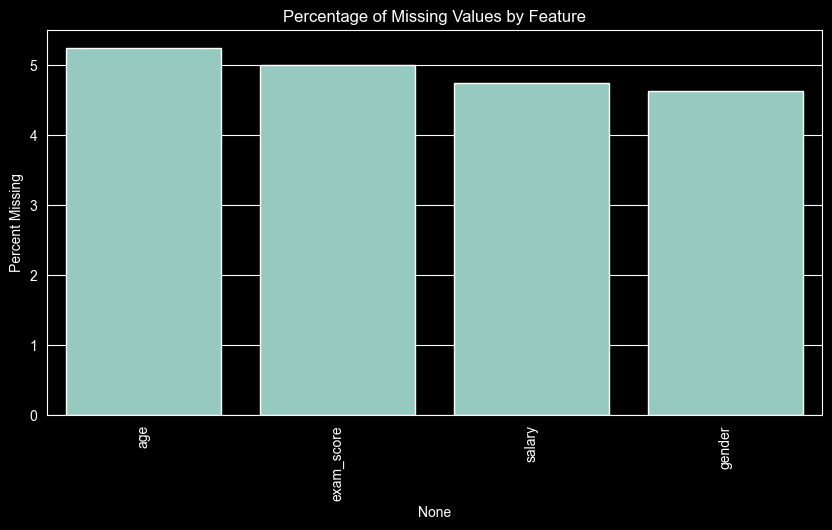

In [10]:
def print_missing_values(df):
  missing = df.isnull().sum()
  missing = missing[missing>0]
  print(missing)

  missing_percent = (missing / len(df)) * 100
  missing_percent.sort_values(ascending=False, inplace=True)
  # Visualize the missing data
  plt.figure(figsize=(10, 5))
  sns.barplot(x=missing_percent.index, y=missing_percent.values)
  plt.xticks(rotation=90)
  plt.title("Percentage of Missing Values by Feature")
  plt.ylabel("Percent Missing")
  plt.show()

print_missing_values(df)

In [11]:
df["age"] = df["age"].fillna(df["age"].median())

In [12]:
df["salary"] = df["salary"].fillna(df["salary"].median())

In [13]:
df["exam_score"] = df["exam_score"].fillna(df["exam_score"].median())

In [14]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

Series([], dtype: int64)


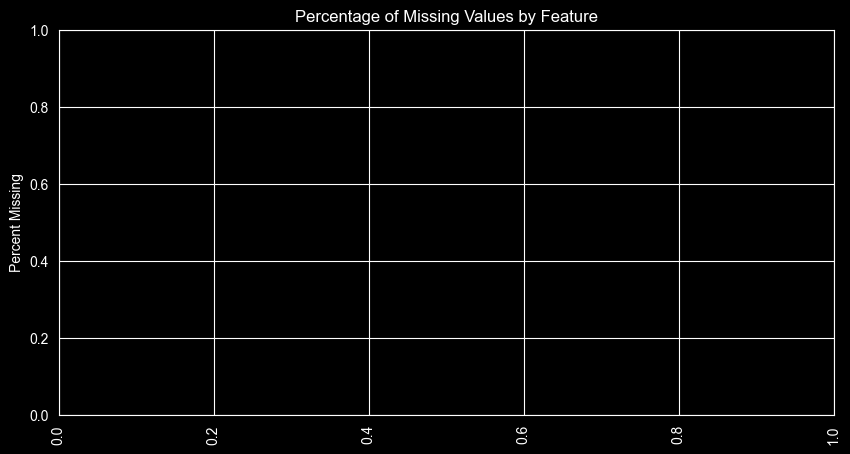

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

def print_missing_values(df):
  missing = df.isnull().sum()
  missing = missing[missing>0]
  print(missing)

  missing_percent = (missing / len(df)) * 100
  missing_percent.sort_values(ascending=False, inplace=True)
  # Visualize the missing data
  plt.figure(figsize=(10, 5))
  sns.barplot(x=missing_percent.index, y=missing_percent.values)
  plt.xticks(rotation=90)
  plt.title("Percentage of Missing Values by Feature")
  plt.ylabel("Percent Missing")
  plt.show()

print_missing_values(df)

In [16]:
df["gender"].unique()
df["gender"].value_counts()

gender
Male      422
Female    347
f          17
male       16
FEMALE     10
M           8
Name: count, dtype: int64

In [17]:
type(df["gender"])

pandas.core.series.Series

In [18]:
df["gender"] = df["gender"].str.lower()
df["gender"] = df["gender"].replace({"m": "male"})
df["gender"] = df["gender"].replace({"f": "female"})

In [19]:
df["gender"].unique()
df["gender"].value_counts()

gender
male      446
female    374
Name: count, dtype: int64

In [20]:
# Check duplicate rows
df.duplicated().sum()

np.int64(20)

Returns a Boolean Series:
- False → first appearance
- True → duplicate

In [21]:
df[df.duplicated()]
# The first occurrence is kept

,name,age,gender,salary,exam_score
165,Student_244,22.0,male,47410.59,75.01
274,Student_395,40.0,female,56607.12,85.70
278,Student_533,33.0,female,72360.89,80.92
337,Student_346,52.0,female,33555.87,78.77
354,Student_66,32.0,male,54287.98,75.01
387,Student_286,29.0,female,65454.25,66.90
425,Student_490,41.0,female,55828.68,78.27
428,Student_65,48.0,male,44184.48,74.77
442,Student_456,54.0,male,75088.59,70.24
465,Student_610,18.0,female,69922.91,62.50


In [22]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

When Should We Remove Duplicates?
When:
- Duplicates are clearly accidental
- They represent data entry error
- Each row should represent a unique entity


Be careful when:
- Repeated entries are meaningful
- Multiple purchases, multiple exam attempts, multiple medical visits

In [23]:
df = df.drop_duplicates(subset="name")

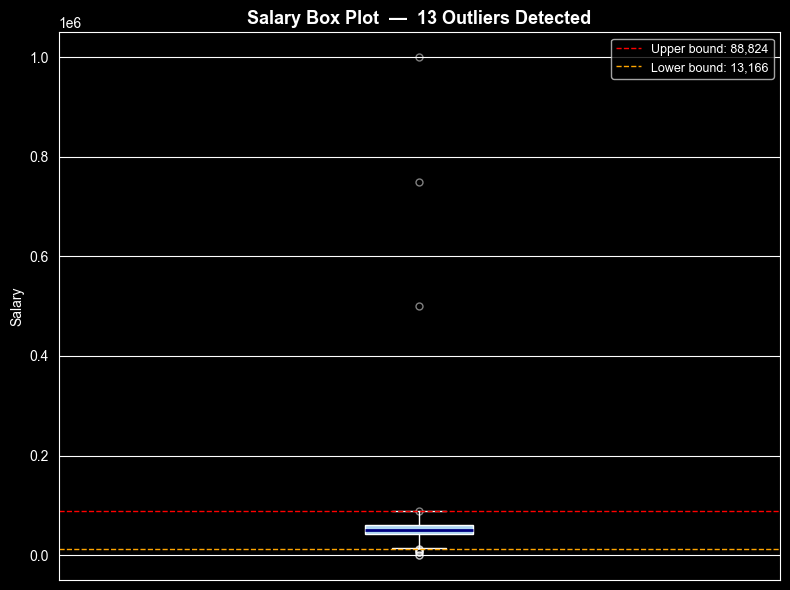

Lower bound: 13,166.43
Upper bound: 88,824.46

Outliers (13):
             name      salary
19   Student_360    12508.91
41   Student_109        5.00
150  Student_101   500000.00
203  Student_739     6916.07
290  Student_653    89025.25
374  Student_525        2.00
416  Student_261     7271.86
485  Student_513  1000000.00
510  Student_301     6556.17
541  Student_791     6179.74
691  Student_546    11691.18
702  Student_722   750000.00
741  Student_555    11134.37


In [24]:
# IQR Outlier Detection
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["salary"] < lower_bound) | (df["salary"] > upper_bound)]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(df["salary"].dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor="#AED6F1"),
           medianprops=dict(color="navy", linewidth=2),
           flierprops=dict(marker="o", color="red", alpha=0.5, markersize=5))

ax.set_title(f"Salary Box Plot  —  {len(outliers)} Outliers Detected", fontsize=13, fontweight="bold")
ax.set_ylabel("Salary")
ax.set_xticks([])

# Annotate bounds
ax.axhline(upper_bound, color="red",    linestyle="--", linewidth=1, label=f"Upper bound: {upper_bound:,.0f}")
ax.axhline(lower_bound, color="orange", linestyle="--", linewidth=1, label=f"Lower bound: {lower_bound:,.0f}")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("salary_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Lower bound: {lower_bound:,.2f}")
print(f"Upper bound: {upper_bound:,.2f}")
print(f"\nOutliers ({len(outliers)}):\n", outliers[["name", "salary"]])

In [25]:
df = df[(df["salary"] >= lower_bound) & (df["salary"] <= upper_bound)]